In [1]:
!pip install numpy pandas matplotlib scikit-learn seaborn


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss, classification_report, confusion_matrix


In [3]:
!pip install kaggle


In [4]:
from google.colab import files
files.upload()  # Select the kaggle.json file


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"ayushkumarr","key":"b8a6af184d1bd22a87f3c5ddecd47ac7"}'}

In [5]:
!pip install -q kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [6]:
!kaggle datasets download -d ankushpanday1/lung-cancer-risk-and-prediction-dataset


Dataset URL: https://www.kaggle.com/datasets/ankushpanday1/lung-cancer-risk-and-prediction-dataset
License(s): Community Data License Agreement - Permissive - Version 1.0
  0% 0.00/15.4M [00:00<?, ?B/s]
100% 15.4M/15.4M [00:00<00:00, 1.29GB/s]


In [ ]:
import zipfile

# Unzip the dataset
with zipfile.ZipFile("lung-cancer-dataset.zip", 'r') as zip_ref:
    zip_ref.extractall("lung_cancer_data")

print("Dataset downloaded and extracted successfully!")


Dataset downloaded and extracted successfully!


In [ ]:
import pandas as pd

# Load the dataset, specifying the correct path
df = pd.read_csv("lung_cancer_data/lung_cancer_examples.csv")  # Updated path

# Show the first 5 rows
print(df.head())

     Name      Surname  Age  Smokes  AreaQ  Alkhol  Result
0    John         Wick   35       3      5       4       1
1    John  Constantine   27      20      2       5       1
2  Camela     Anderson   30       0      5       2       0
3    Alex       Telles   28       0      8       1       0
4   Diego     Maradona   68       4      5       6       1


In [ ]:
# Display first few rows
print(df.head())

# Show dataset info (columns, data types, null values)
print(df.info())

# Check for missing values
print(df.isnull().sum())

# Summary statistics
print(df.describe())


     Name      Surname  Age  Smokes  AreaQ  Alkhol  Result
0    John         Wick   35       3      5       4       1
1    John  Constantine   27      20      2       5       1
2  Camela     Anderson   30       0      5       2       0
3    Alex       Telles   28       0      8       1       0
4   Diego     Maradona   68       4      5       6       1
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59 entries, 0 to 58
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Name     59 non-null     object
 1   Surname  59 non-null     object
 2   Age      59 non-null     int64 
 3   Smokes   59 non-null     int64 
 4   AreaQ    59 non-null     int64 
 5   Alkhol   59 non-null     int64 
 6   Result   59 non-null     int64 
dtypes: int64(5), object(2)
memory usage: 3.4+ KB
None
Name       0
Surname    0
Age        0
Smokes     0
AreaQ      0
Alkhol     0
Result     0
dtype: int64
             Age     Smokes      AreaQ     Alkhol   

In [ ]:
# Check column names
print(df.columns)


Index(['Name', 'Surname', 'Age', 'Smokes', 'AreaQ', 'Alkhol', 'Result'], dtype='object')


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Drop irrelevant columns
df = df.drop(columns=['Name', 'Surname'])  # Names are not useful for prediction

# Define features (X) and target (y)
X = df.drop(columns=['Result'])  # 'Result' is the target (Lung Cancer: Yes/No)
y = df['Result']

# Convert target variable to numeric (assuming 'Yes' = 1, 'No' = 0)
y = y.map({'YES': 1, 'NO': 0})  # Make sure values match exactly

# Check for missing values
print(df.isnull().sum())

# Split data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize numerical features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


Age       0
Smokes    0
AreaQ     0
Alkhol    0
Result    0
dtype: int64


In [ ]:
print(y.isnull().sum())  # Check for missing values


59


In [ ]:
df = df.dropna(subset=['Result'])  # Remove only rows where 'Result' is NaN


In [ ]:
df['Result'] = df['Result'].fillna(df['Result'].mode()[0])


In [ ]:
print(df['Result'].isnull().sum())  # Should print 59


0


In [ ]:
print(pd.DataFrame(X_train).isnull().sum())  # Check for NaNs in each column


0    0
1    0
2    0
3    0
dtype: int64


In [ ]:
print(X_train.shape, y_train.shape)  # Check number of samples



(47, 4) (47,)


In [ ]:
print(X_train.dtypes)


AttributeError: 'numpy.ndarray' object has no attribute 'dtypes'

In [ ]:
import pandas as pd

# Convert X_train back to DataFrame
X_train_df = pd.DataFrame(X_train, columns=df.drop(columns=['Result']).columns)

# Check data types
print(X_train_df.dtypes)


Age       float64
Smokes    float64
AreaQ     float64
Alkhol    float64
dtype: object


In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)  # Should work now!


ValueError: Input y contains NaN.

In [ ]:
print(y_train.isnull().sum())  # Should print 0


47


In [ ]:
print(y.isnull().sum())  # If > 0, you need to fix y before splitting


59


In [ ]:
print(y.isnull().sum())  # Check total NaN values in y
print(y.shape)           # Check total rows in y
print(y.head())          # Look at first few rows


59
(59,)
0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
Name: Result, dtype: float64


In [ ]:
df['Result'] = df['Result'].fillna(df['Result'].mode()[0])  # Fill with most frequent class


In [ ]:
print(df['Result'].isnull().sum())  # Should print 0
print(df['Result'].value_counts())  # See class distribution


0
Result
0    31
1    28
Name: count, dtype: int64


In [ ]:
X = df.drop(columns=['Result'])  # Features
y = df['Result']                 # Target


In [ ]:
X = X.loc[y.index]  # Keep only rows where y is valid


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)  # 🚀 Should work now!


LogisticRegression()

In [ ]:
from sklearn.metrics import accuracy_score

# Make predictions
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")


Model Accuracy: 0.92


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.89      1.00      0.94         8
           1       1.00      0.75      0.86         4

    accuracy                           0.92        12
   macro avg       0.94      0.88      0.90        12
weighted avg       0.93      0.92      0.91        12



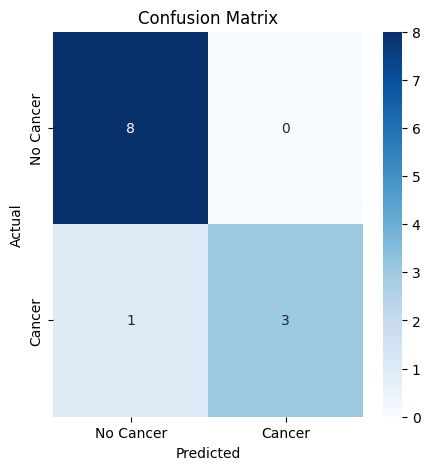

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Cancer', 'Cancer'], yticklabels=['No Cancer', 'Cancer'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
# Example patient data: [Age, Smokes, AreaQ, Alkhol]
new_patient = [[55, 1, 3, 1]]  # Adjust values based on your dataset

prediction = model.predict(new_patient)
print("Lung Cancer Prediction:", "Positive" if prediction[0] == 1 else "Negative")


Lung Cancer Prediction: Negative


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
